In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 


from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix, precision_score, recall_score





class MalariaML:

    def __init__(self, file_path):
        print("Loading dataset.....")
        self.file_path = file_path
        self.df = pd.read_csv(file_path)
        self.target = None
        print("Dataset loaded successfully\n")


    
    #View Dataset
    def explore_data(self):
        print("First 5 rows:")
        print(self.df.head())
        print("\n Info:")
        print(self.df.info())
        print("\n Missing values:")
        print(self.df.isnull().sum())
    


    #Cleaning 
    def clean_data(self):
        print("\n Cleaning data...")

        #Drop duplicates
        self.df = self.df.drop_duplicates()

        #fill missing values
        self.df = self.df.fillna(method="ffill").fillna(method="bfill")
        print('Cleaning done\n')

    
    def handle_columns(self):
        self.df.columns = (self.df.columns.astype(str)
                .str.lower()
                .str.strip()
                .str.replace(" ", "_", regex=False)
                .str.replace(")", "", regex=False)
                .str.replace("(", "", regex=False)
                .str.replace("%", "", regex=False)
                )

        
        self.df = self.df.rename(columns={
        'country_name': 'country',
        'year': 'year',
        'country_code': 'country_code',
        'incidence_of_malaria_per_1,000_population_at_risk': 'incidence_per_1000',
       'malaria_cases_reported':  'malaria_cases_reported' ,
       'use_of_insecticide-treated_bed_nets__of_under-5_population': 'use_of_insecticide_per_population',
       'children_with_fever_receiving_antimalarial_drugs__of_children_under_age_5_with_fever':  'children_with_under_age_5_fever',
       'intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy__of_pregnant_women': 'ipt_of_malaria_pregnant_women',
       'people_using_safely_managed_drinking_water_services__of_population': 'ppl_drinking_water_serv_pop',
       'people_using_safely_managed_drinking_water_services,_rural__of_rural_population': 'ppl_drinking_water_serv_rural_pop',
       'people_using_safely_managed_drinking_water_services,_urban__of_urban_population':  'ppl_drinking_water_serv_urban_pop',
       'people_using_safely_managed_sanitation_services__of_population': 'ppl_sanitation_services__of_population',
       'people_using_safely_managed_sanitation_services,_rural__of_rural_population': 'ppl_sanitation_services__of_rural_pop',
       'people_using_safely_managed_sanitation_services,_urban___of_urban_population': 'ppl_sanitation_services__of_urban_pop',
       'rural_population__of_total_population': "rural_tot_pop",
       'rural_population_growth_annual_': 'rural_pop_growth_ann',
       'urban_population__of_total_population': 'urban_tot_pop',
       'urban_population_growth_annual_': 'urban_pop_growth_ann',
       'people_using_at_least_basic_drinking_water_services__of_population': 'ppl_basic_drinking_water_pop' ,
       'people_using_at_least_basic_drinking_water_services,_rural__of_rural_population': 'ppl_basic_drinking_water_rural_pop' ,
       'people_using_at_least_basic_drinking_water_services,_urban__of_urban_population': 'ppl_basic_drinking_water_urban_pop',
       'people_using_at_least_basic_sanitation_services__of_population': 'ppl_using_basic_sanitation_pop',
       'people_using_at_least_basic_sanitation_services,_rural__of_rural_population': 'ppl_using_basic_sanit_rural_of_rural_pop',
       'people_using_at_least_basic_sanitation_services,_urban___of_urban_population': 'ppl_using_basic_sanit_urban_of_urban_pop',
       'latitude': 'latitude',
        'longitude': 'longitude',
        'geometry': 'geometry'
        })



        self.df.drop(columns=['country_code', 'year', 'country'])

        print("Handling and Column Dropping Done")

    def create_target(self):

        def calculate_risk(malaria_cases, bednet):
            return (1 if malaria_cases > 100000 and bednet < 50 else 0)
    
        self.df["malaria"] = self.df.apply(lambda r: calculate_risk(r['malaria_cases_reported'],
                                                                    r['use_of_insecticide_per_population']),
                                                                    axis=1
                                                                    )
    def visualise(self):
        print("Visualising......")

        self.df.hist(figsize=(10, 6))
        plt.tight_layout()
        plt.show()

    #Define Features and Targets
    def define_target(self):
        print("Defining target........")

        #We assume malaria column exists (adjust if needed)

        self.target = 'malaria'
        
 
        self.X = self.df.drop(columns=[self.target])
        self.y = self.df[self.target]

        print(f"Target column: {self.target}\n")
 

    #Preprocessing (VERY IMPORTANT)
    def preprocess(self):
        print(" Preprocessing......")

        #Separate numerical and categorical 
        self.num_cols = self.X.select_dtypes(include=['int64', 'float64']).columns
        self.cat_cols = self.X.select_dtypes(include=['object']).columns

        print("Numerical columns:", self.num_cols)
        print("Categorical columns:", self.cat_cols)


        #Transformers
        num_transformer = StandardScaler()
        cat_transformer = OneHotEncoder(handle_unknown='ignore')

        self.preprocessor = ColumnTransformer(transformers=[
            ('num', num_transformer, self.num_cols),
            ('cat', cat_transformer, self.cat_cols)
        ] 
        
        )
    
    def split_data(self):
        print("\n Splitting data.....")
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(self.X, self.y, test_size=0.2, random_state=42, stratify=self.y
        )

        print("Data split complete\n")

    #Build Pipeline
    def build_model(self):
        print(" Building pipeline...")

        self.pipeline = Pipeline(steps=[

            ('preprocessing', self.preprocessor),
            ('model', RandomForestClassifier(n_estimators=100, random_state=42))
        ])

        print(" Pipeline ready\n")


    # Train Model
    def train(self):
        print(" Training model.....")

        self.pipeline.fit(self.X_train, self.y_train)

        print("Training complete")



    
    def evaluate(self):
        print('Evaluating model')

        y_pred = self.pipeline.predict(self.X_test)
        y_proba = self.pipeline.predict_proba(self.X_test)[:, 1]

        acc = accuracy_score(self.y_test, y_pred)
        roc = roc_auc_score(self.y_test, y_proba)


        print('Accuracy:', acc)
        print("ROC AUC:", roc)


        print("\nConfusion Matrix:")
        print(confusion_matrix(self.y_test, y_pred))



    #Cross Validation
    def cross_validate(self):
        print("\n Cross-validating....")

        self.cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=43)

        self.scoring = {
            "accuracy": "accuracy",
            "precision": "precision",
            "roc_auc": "roc_auc",
            "f1": "f1",
            "recall": "recall"
        }

        results = cross_validate(self.pipeline, self.X, self.y, cv=self.cv, scoring=self.scoring, return_train_score=False)


        print("Mean Test_ROC_AUC:", round(results["test_roc_auc"].mean(), 2))
        print("Mean Test_Precision:", round(results["test_precision"].mean(), 2))
        print("Mean Test_accuracy:", round(results["test_accuracy"].mean(), 2))
        print("Mean Test_recall:", round(results["test_recall"].mean(), 2))
        print("Mean Test_f1:", round(results["test_f1"].mean(), 2))


    #Hyperparameter tuning

    def tune_model(self):
        print("\n Hyperparameter tuning.....")

        param_grid = {

            'model__n_estimators': [50, 100],
            'model__max_depth': [None, 5, 10]

        }


        grid = GridSearchCV(self.pipeline, param_grid=param_grid, cv=self.cv, scoring="accuracy")
        grid.fit(self.X_train, self.y_train)

        print("Best parameters:", grid.best_params_)
        self.pipeline = grid.best_estimator_



Loading dataset.....
Dataset loaded successfully

First 5 rows:
   Country Name  Year  ...  longitude                            geometry
0       Algeria  2007  ...   1.659626          POINT (28.033886 1.659626)
1        Angola  2007  ...  17.873887        POINT (-11.202692 17.873887)
2         Benin  2007  ...   2.315834  POINT (9.307689999999999 2.315834)
3      Botswana  2007  ...  24.684866        POINT (-22.328474 24.684866)
4  Burkina Faso  2007  ...  -1.561593         POINT (12.238333 -1.561593)

[5 rows x 27 columns]

 Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594 entries, 0 to 593
Data columns (total 27 columns):
 #   Column                                                                                   Non-Null Count  Dtype  
---  ------                                                                                   --------------  -----  
 0   Country Name                                                                             594 non-null    object 
 1

C:\Users\user\AppData\Local\Temp\ipykernel_30960\1735311374.py:47: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  self.df = self.df.fillna(method="ffill").fillna(method="bfill")


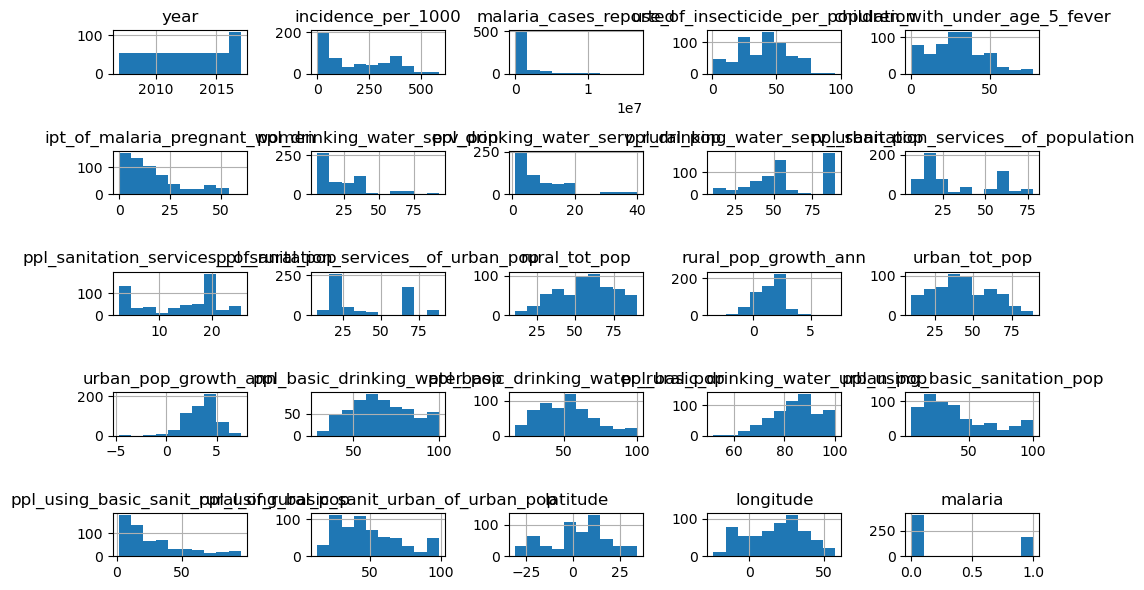

Defining target........
Target column: malaria

 Preprocessing......
Numerical columns: Index(['year', 'incidence_per_1000', 'malaria_cases_reported',
       'use_of_insecticide_per_population', 'children_with_under_age_5_fever',
       'ipt_of_malaria_pregnant_women', 'ppl_drinking_water_serv_pop',
       'ppl_drinking_water_serv_rural_pop',
       'ppl_drinking_water_serv_urban_pop',
       'ppl_sanitation_services__of_population',
       'ppl_sanitation_services__of_rural_pop',
       'ppl_sanitation_services__of_urban_pop', 'rural_tot_pop',
       'rural_pop_growth_ann', 'urban_tot_pop', 'urban_pop_growth_ann',
       'ppl_basic_drinking_water_pop', 'ppl_basic_drinking_water_rural_pop',
       'ppl_basic_drinking_water_urban_pop', 'ppl_using_basic_sanitation_pop',
       'ppl_using_basic_sanit_rural_of_rural_pop',
       'ppl_using_basic_sanit_urban_of_urban_pop', 'latitude', 'longitude'],
      dtype='object')
Categorical columns: Index(['country', 'country_code', 'geometry'], dty

In [7]:
ml = MalariaML("DatasetAfricaMalaria.csv")

#Let us Run it Step by Step


ml.explore_data()
ml.clean_data()
ml.handle_columns()
ml.create_target()
ml.visualise()
ml.define_target()
ml.preprocess()
ml.split_data()
ml.build_model()
ml.train()
ml.evaluate()
ml.cross_validate()
ml.tune_model()

In [8]:

import pandas as pd 

df = pd.read_csv("DatasetAfricaMalaria.csv")

df.columns = (df.columns.astype(str)
                .str.lower()
                .str.strip()
                .str.replace(" ", "_", regex=False)
                .str.replace(")", "", regex=False)
                .str.replace("(", "", regex=False)
                .str.replace("%", "", regex=False)
                
                )
                

In [9]:
df.columns

Index(['country_name', 'year', 'country_code',
       'incidence_of_malaria_per_1,000_population_at_risk',
       'malaria_cases_reported',
       'use_of_insecticide-treated_bed_nets__of_under-5_population',
       'children_with_fever_receiving_antimalarial_drugs__of_children_under_age_5_with_fever',
       'intermittent_preventive_treatment_ipt_of_malaria_in_pregnancy__of_pregnant_women',
       'people_using_safely_managed_drinking_water_services__of_population',
       'people_using_safely_managed_drinking_water_services,_rural__of_rural_population',
       'people_using_safely_managed_drinking_water_services,_urban__of_urban_population',
       'people_using_safely_managed_sanitation_services__of_population',
       'people_using_safely_managed_sanitation_services,_rural__of_rural_population',
       'people_using_safely_managed_sanitation_services,_urban___of_urban_population',
       'rural_population__of_total_population',
       'rural_population_growth_annual_',
       'urba

In [10]:
df["malaria_cases_reported"].describe()

count    5.500000e+02
mean     1.068330e+06
std      2.192802e+06
min      0.000000e+00
25%      2.211750e+03
50%      1.130260e+05
75%      1.154808e+06
max      1.682113e+07
Name: malaria_cases_reported, dtype: float64

In [11]:
df.shape

(594, 27)

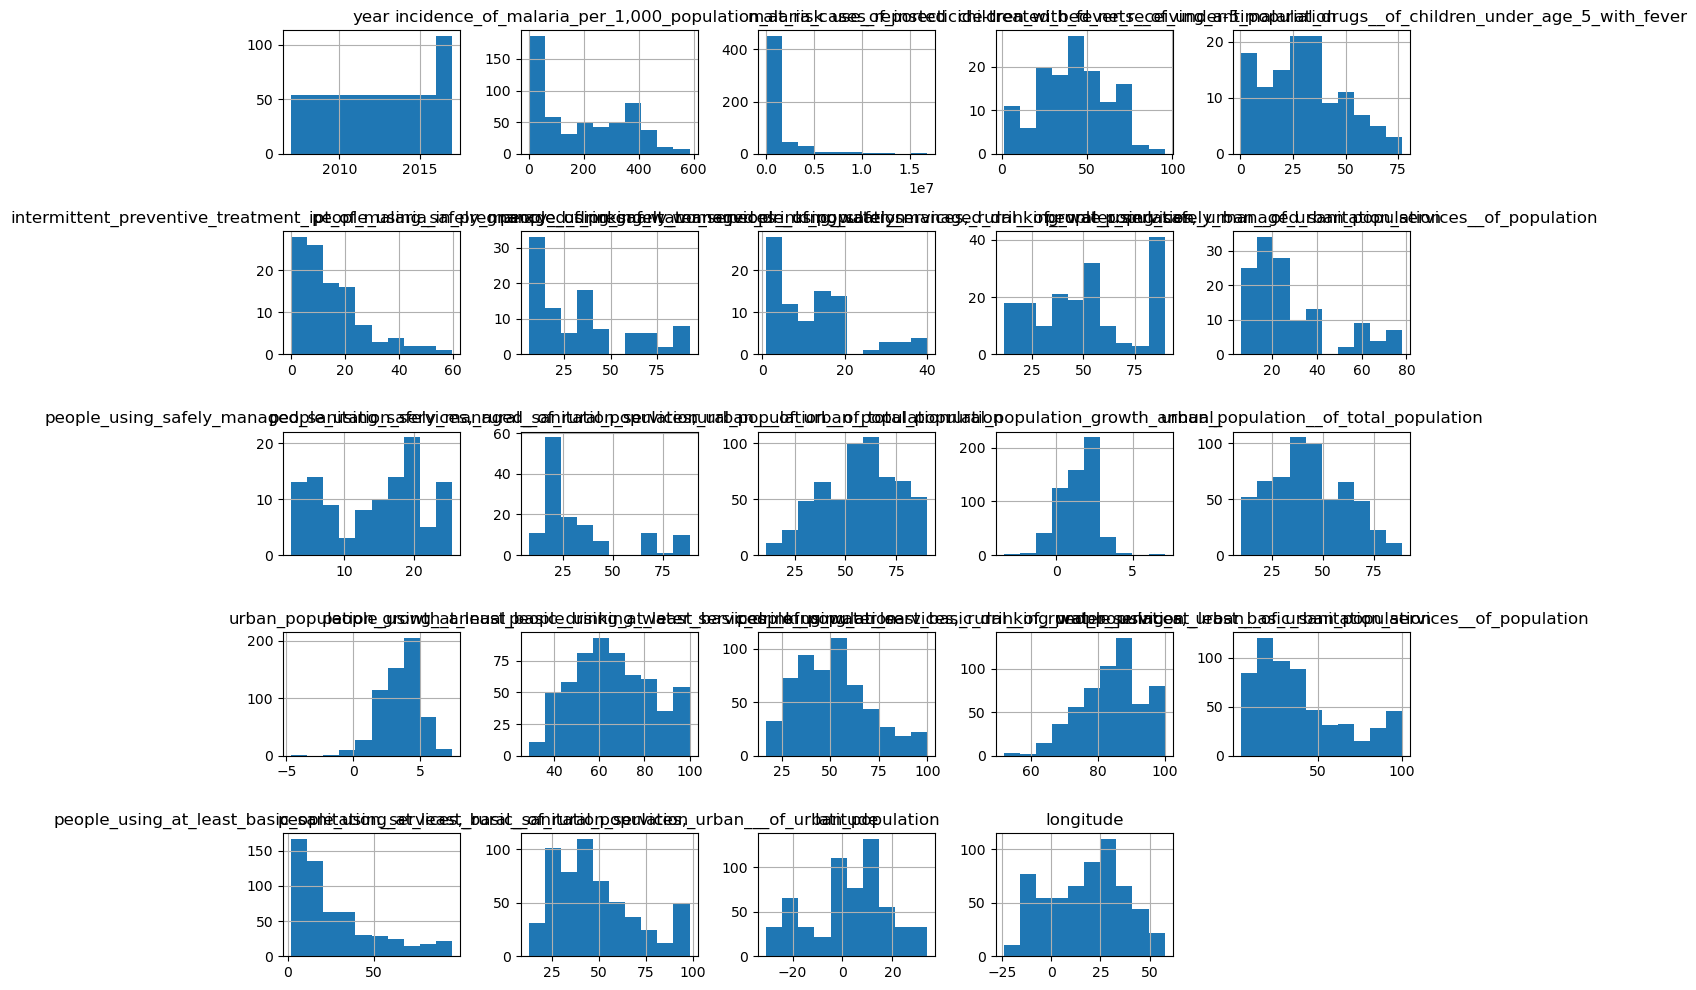

In [12]:
import matplotlib.pyplot as plt 

df.hist(figsize=(12, 10))
plt.tight_layout()
plt.show()
